In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('fivethirtyeight')
df = pd.read_csv('D:\\Case Study\\data\\heart_ready.csv')

In [10]:

plt.style.use('fivethirtyeight')
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv('D:\\Case Study\\data\\heart_ready.csv')

# Tạo binary target nếu chưa có
if df['target'].max() > 1:
    df['target'] = (df['target'] > 0).astype(int)

continuous  = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

print(f"Shape: {df.shape}")
print(f"Target: {df['target'].value_counts().to_dict()}")

Shape: (1631, 14)
Target: {1: 856, 0: 775}


In [11]:

print("Xác suất có điều kiện P(bệnh tim | cp):")
print("=" * 45)
for cp_val in sorted(df['cp'].unique()):
    subset = df[df['cp'] == cp_val]
    p = subset['target'].mean()
    bar = '█' * int(p * 20)
    print(f"  P(bệnh | cp={cp_val}) = {p:.3f}  {bar}")

print(f"\n  P(bệnh) tổng quát    = {df['target'].mean():.3f}")

# Xác suất đồng thời — P(cp >= 1 và bệnh)
p_joint = ((df['cp'] >= 1) & (df['target'] == 1)).mean()
p_cp    = (df['cp'] >= 1).mean()
p_given = p_joint / p_cp   
print(f"\n  P(cp≥1 và bệnh)      = {p_joint:.3f}")
print(f"  P(cp≥1)              = {p_cp:.3f}")
print(f"  P(bệnh | cp≥1)       = {p_given:.3f}  ← Xác suất có điều kiện")

Xác suất có điều kiện P(bệnh tim | cp):
  P(bệnh | cp=0) = 0.255  █████
  P(bệnh | cp=1) = 0.809  ████████████████
  P(bệnh | cp=2) = 0.779  ███████████████
  P(bệnh | cp=3) = 0.675  █████████████

  P(bệnh) tổng quát    = 0.525

  P(cp≥1 và bệnh)      = 0.402
  P(cp≥1)              = 0.520
  P(bệnh | cp≥1)       = 0.774  ← Xác suất có điều kiện


Population thalach: mean=149.31, std=22.95
Phân phối gốc: lệch (không chuẩn)


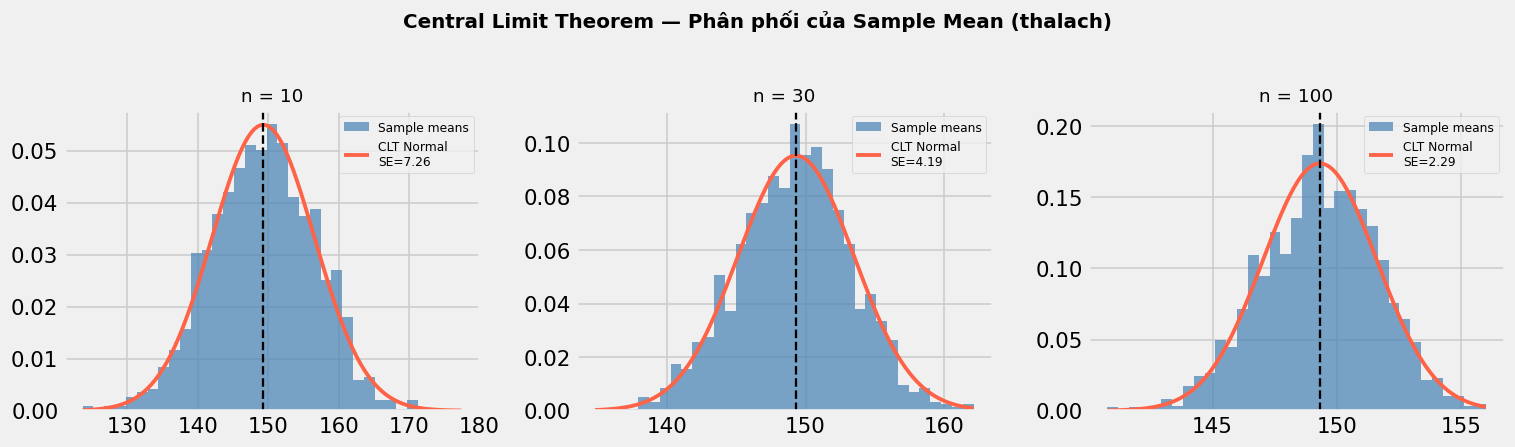

In [12]:


population = df['thalach'].values
pop_mean   = np.mean(population)
pop_std    = np.std(population)

print(f"Population thalach: mean={pop_mean:.2f}, std={pop_std:.2f}")
print(f"Phân phối gốc: lệch (không chuẩn)")

# Lấy mẫu nhiều lần → phân phối của sample mean
n_samples      = 2000
sample_sizes   = [10, 30, 100]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, n in zip(axes, sample_sizes):
    sample_means = [
        np.mean(np.random.choice(population, n, replace=True))
        for _ in range(n_samples)
    ]
    # SE lý thuyết theo CLT = std / sqrt(n)
    se_theory = pop_std / np.sqrt(n)

    ax.hist(sample_means, bins=35, density=True,
            color='steelblue', alpha=0.7, label='Sample means')

    # Overlay Normal theo CLT
    x = np.linspace(min(sample_means), max(sample_means), 200)
    normal_curve = (
        np.exp(-0.5 * ((x - pop_mean) / se_theory) ** 2)
        / (se_theory * np.sqrt(2 * np.pi))
    )
    ax.plot(x, normal_curve, color='tomato', linewidth=2.5,
            label=f'CLT Normal\nSE={se_theory:.2f}')
    ax.axvline(pop_mean, color='black', linestyle='--', linewidth=1.5)
    ax.set_title(f'n = {n}', fontsize=12)
    ax.legend(fontsize=8)

plt.suptitle('Central Limit Theorem — Phân phối của Sample Mean (thalach)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [13]:
# Độ chính xác tăng theo căn bậc hai kích thước mẫu

print("Square Root Law — SE = std / sqrt(n):")
print("=" * 50)
print(f"{'n':>8} {'SE':>10} {'SE giảm so với n=10':>22}")
print("=" * 50)

se_base = pop_std / np.sqrt(10)
for n in [10, 40, 90, 160, 250]:
    se = pop_std / np.sqrt(n)
    ratio = se_base / se
    print(f"{n:>8} {se:>10.4f} {ratio:>20.1f}x chính xác hơn")

print(f"\n→ Tăng n từ 10 lên 90 (×9): SE giảm đúng 3× (√9 = 3)")

Square Root Law — SE = std / sqrt(n):
       n         SE    SE giảm so với n=10
      10     7.2570                  1.0x chính xác hơn
      40     3.6285                  2.0x chính xác hơn
      90     2.4190                  3.0x chính xác hơn
     160     1.8143                  4.0x chính xác hơn
     250     1.4514                  5.0x chính xác hơn

→ Tăng n từ 10 lên 90 (×9): SE giảm đúng 3× (√9 = 3)


In [14]:
# Bootstrap: lấy mẫu lại từ sample để ước lượng CI
def bootstrap_ci(data, stat_func, n_boot=2000, ci=95):
   
    boot_stats = [
        stat_func(np.random.choice(data, len(data), replace=True))
        for _ in range(n_boot)
    ]
    lower = np.percentile(boot_stats, (100 - ci) / 2)
    upper = np.percentile(boot_stats, 100 - (100 - ci) / 2)
    return np.array(boot_stats), lower, upper

# Ước lượng CI cho mean thalach của nhóm bệnh
group_sick  = df[df['target'] == 1]['thalach'].values
group_well  = df[df['target'] == 0]['thalach'].values

boot_sick, lo_sick, hi_sick = bootstrap_ci(group_sick, np.mean)
boot_well, lo_well, hi_well = bootstrap_ci(group_well, np.mean)

print("95% Bootstrap Confidence Interval — Mean thalach:")
print(f"  Bệnh tim  : mean={np.mean(group_sick):.2f}  "
      f"CI = [{lo_sick:.2f}, {hi_sick:.2f}]")
print(f"  Không bệnh: mean={np.mean(group_well):.2f}  "
      f"CI = [{lo_well:.2f}, {hi_well:.2f}]")

ci_overlap = lo_sick < hi_well and lo_well < hi_sick
print(f"\n  CI overlap? {'Có → khó kết luận' if ci_overlap else 'Không → 2 nhóm khác nhau rõ rệt'}")

95% Bootstrap Confidence Interval — Mean thalach:
  Bệnh tim  : mean=158.54  CI = [157.25, 159.81]
  Không bệnh: mean=139.12  CI = [137.52, 140.69]

  CI overlap? Không → 2 nhóm khác nhau rõ rệt


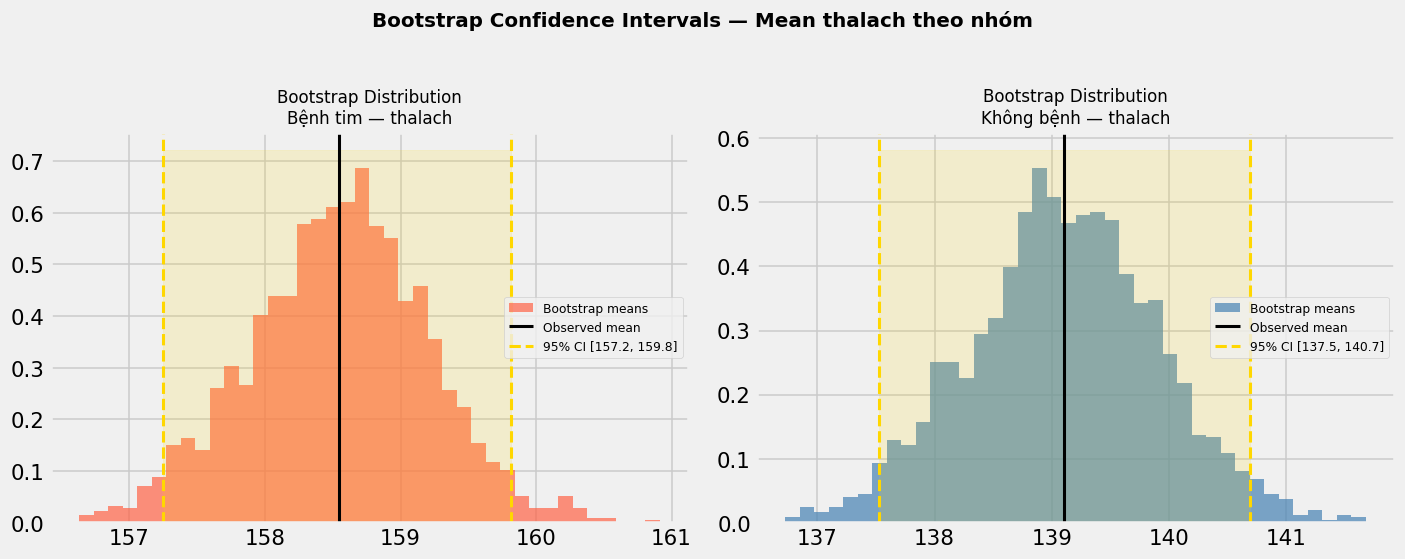

In [15]:
# Visualize bootstrap distribution + CI
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, boot, lo, hi, name, color in zip(
    axes,
    [boot_sick, boot_well],
    [lo_sick, lo_well],
    [hi_sick, hi_well],
    ['Bệnh tim', 'Không bệnh'],
    ['tomato', 'steelblue']
):
    ax.hist(boot, bins=40, color=color, alpha=0.7,
            density=True, label='Bootstrap means')
    ax.axvline(np.mean(boot), color='black',
               linestyle='-', linewidth=2, label='Observed mean')
    ax.axvline(lo, color='gold', linestyle='--',
               linewidth=2, label=f'95% CI [{lo:.1f}, {hi:.1f}]')
    ax.axvline(hi, color='gold', linestyle='--', linewidth=2)
    ax.fill_betweenx(
        [0, ax.get_ylim()[1] if len(ax.get_lines()) > 0 else 0.1],
        lo, hi, alpha=0.15, color='gold'
    )
    ax.set_title(f'Bootstrap Distribution\n{name} — thalach', fontsize=11)
    ax.legend(fontsize=8)

plt.suptitle('Bootstrap Confidence Intervals — Mean thalach theo nhóm',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [16]:
print("=" * 65)
print("95% Bootstrap CI — Mean mỗi feature theo nhóm bệnh")
print("=" * 65)
print(f"{'Feature':<12} {'Mean(No)':>10} {'CI No':>18} "
      f"{'Mean(Yes)':>10} {'CI Yes':>18} {'Overlap?':>10}")
print("=" * 65)

week2_rows = []
for col in continuous:
    g0 = df[df['target'] == 0][col].values
    g1 = df[df['target'] == 1][col].values

    _, lo0, hi0 = bootstrap_ci(g0, np.mean, n_boot=1000)
    _, lo1, hi1 = bootstrap_ci(g1, np.mean, n_boot=1000)
    overlap = lo1 < hi0 and lo0 < hi1

    week2_rows.append({
        'feature': col,
        'mean_0': np.mean(g0), 'lo_0': lo0, 'hi_0': hi0,
        'mean_1': np.mean(g1), 'lo_1': lo1, 'hi_1': hi1,
        'ci_overlap': overlap
    })
    ci0 = f"[{lo0:.1f},{hi0:.1f}]"
    ci1 = f"[{lo1:.1f},{hi1:.1f}]"
    ov  = "Có" if overlap else "Không "
    print(f"{col:<12} {np.mean(g0):>10.2f} {ci0:>18} "
          f"{np.mean(g1):>10.2f} {ci1:>18} {ov:>10}")

week2_df = pd.DataFrame(week2_rows)
week2_df.to_csv('D:\\Case Study\\data\\week2_ci.csv', index=False)
print("\n Đã lưu week2_ci.csv")

95% Bootstrap CI — Mean mỗi feature theo nhóm bệnh
Feature        Mean(No)              CI No  Mean(Yes)             CI Yes   Overlap?
age               56.58        [56.0,57.1]      52.44        [51.8,53.0]     Không 
trestbps         134.21      [133.0,135.5]     129.27      [128.2,130.4]     Không 


chol             251.22      [247.8,254.8]     241.46      [238.0,245.2]     Không 
thalach          139.12      [137.6,140.8]     158.54      [157.1,159.9]     Không 
oldpeak            1.59          [1.5,1.7]       0.58          [0.5,0.6]     Không 

 Đã lưu week2_ci.csv
